# League-Wide Temporal Modeling of MLB Team Performance

## Dataset Construction

We construct a team–season dataset from the Lahman baseball database covering the 1985–2016 seasons. Player salaries are aggregated to obtain team payroll, which is log-transformed and normalized within each season to account for inflation and league-wide spending trends. Each row represents one MLB team in one season, with  erformance measured by wins, runs scored, and runs allowed. The resulting dataset contains no missing values and is used consistently across all experiments.

/var/folders/sx/d1p2wx5n3yzbg3s04mdmjvfr0000gn/T/ipykernel_73414/2712160371.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby("bin")["W"].mean()


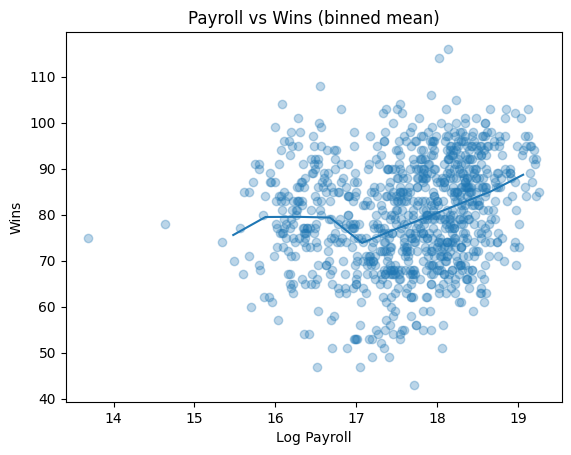

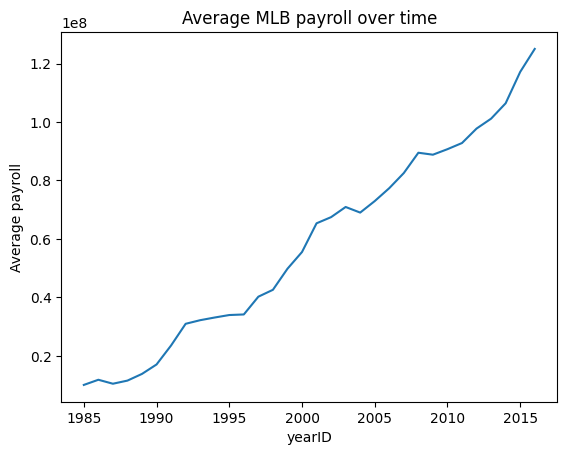

In [1]:
import os
from features import *
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# process raw data
build_processed(start_year=1985, end_year=2016, overwrite=True)

df = pd.read_csv("data/processed.csv")

# use binned mean to show a general relationship between payroll & wins
bins = np.linspace(df["log_payroll"].min(), df["log_payroll"].max(), 15)
df["bin"] = pd.cut(df["log_payroll"], bins=bins)

means = df.groupby("bin")["W"].mean()

plt.figure()
plt.scatter(df["log_payroll"], df["W"], alpha=0.3)
plt.plot([b.mid for b in means.index], means.values)
plt.xlabel("Log Payroll")
plt.ylabel("Wins")
plt.title("Payroll vs Wins (binned mean)")

plt.figure()
df.groupby("yearID")["payroll"].mean().plot()
plt.ylabel("Average payroll")
plt.title("Average MLB payroll over time")
plt.show()



## Feature Engineering


### Temporal Feature Construction

Temporal dependencies are incorporated by constructing lagged features (wins, payroll) from historical team data. For each team-season at time \( t \), the target variable is defined as wins in season \( t+1 \). Lagged features include wins and season-normalized payroll from the previous three seasons. Rows lacking sufficient history are removed,  nsuring a consistent and leakage-free temporal representation. These lagged features provide a time-aware baseline for subsequent modeling.

In [ ]:
df = df.sort_values(["teamID", "yearID"])

# W_next = win in next year
df["W_next"] = df.groupby("teamID")["W"].shift(-1)
df = df.dropna(subset=["W_next"])

# add lagged features for the past 3 yrs
for k in [1, 2, 3]:
    df[f"W_lag{k}"] = df.groupby("teamID")["W"].shift(k)
    df[f"payroll_z_lag{k}"] = df.groupby("teamID")["payroll_z_by_year"].shift(k)

df_lagged = df.dropna().reset_index(drop=True)
df_lagged.head()

,yearID,teamID,lgID,divID,G,W,R,RA,payroll,log_payroll,...,W_pct,pythag_win_pct,bin,W_next,W_lag1,payroll_z_lag1,W_lag2,payroll_z_lag2,W_lag3,payroll_z_lag3
0,2000,ANA,AL,W,162,82,864.0,869.0,51464167,17.756396,...,0.506173,0.497115,"(17.669, 18.068]",75.0,70.0,0.441886,85.0,0.113514,84.0,-0.475717
1,2001,ANA,AL,W,162,75,691.0,730.0,47535167,17.676980,...,0.462963,0.472575,"(17.669, 18.068]",99.0,82.0,0.027756,70.0,0.441886,85.0,0.113514
2,2002,ANA,AL,W,162,99,851.0,644.0,61721667,17.938146,...,0.611111,0.635857,"(17.669, 18.068]",77.0,75.0,-0.614997,82.0,0.027756,70.0,0.441886
3,2003,ANA,AL,W,162,77,736.0,743.0,79031667,18.185359,...,0.475309,0.495267,"(18.068, 18.466]",92.0,99.0,-0.070968,75.0,-0.614997,82.0,0.027756
4,2001,ARI,NL,W,162,92,818.0,677.0,85082999,18.259138,...,0.567901,0.593483,"(18.068, 18.466]",98.0,85.0,1.038977,100.0,0.914487,65.0,-0.443865


In [3]:
# time-aware training
LAG_FEATURES = ["W_lag1", "W_lag2", "W_lag3", "payroll_z_lag1", "payroll_z_lag2", "payroll_z_lag3"]
TARGET = "W_next"

# time-aware data split
train = df_lagged[(df_lagged["yearID"] >= 1985) & (df_lagged["yearID"] <= 2008)]
val   = df_lagged[(df_lagged["yearID"] >= 2009) & (df_lagged["yearID"] <= 2012)]
test  = df_lagged[(df_lagged["yearID"] >= 2013) & (df_lagged["yearID"] <= 2016)]

X_train, y_train = train[LAG_FEATURES], train[TARGET]
X_val, y_val     = val[LAG_FEATURES], val[TARGET]
X_test, y_test   = test[LAG_FEATURES], test[TARGET]

len(X_train), len(X_val), len(X_test)


(572, 118, 88)

## Experimental Setup

- **Prediction task:** Forecast each team’s number of wins in season *t+1* (`W_next`) using information available up to season *t*.
- **Secondary target:** Evaluate an **efficiency-based residual target**, defined as the difference between actual next-season wins and the corresponding model-based expectation.
- **Temporal protocol:** Use a **time-aware train/validation/test split** so that models are always evaluated on future seasons and no temporal leakage occurs.
- **Models:** Compare classical fixed-lag regression baselines with deep temporal models (LSTM, GRU, and Transformer).
- **Evaluation metrics** (units: wins):
  - For **next-season win prediction**: **RMSE**, **MAE**, and **R²**
  - For the **efficiency residual target**: **RMSE** and **MAE**
- **Controlled variants / ablations:** Compare different temporal context lengths and feature subsets such as payroll-only versus fuller contextual inputs.

## Baseline Results

We first evaluate classical linear baselines for next-season win prediction using fixed lag features constructed from the previous 3 seasons. In particular, the baseline feature set includes lagged wins and season-normalized payroll (`payroll_z_by_year`).

We compare **ordinary linear regression** and **ridge regression**. Linear regression provides a simple interpretable benchmark, while ridge regression adds L2 regularization to reduce coefficient instability when lagged features are correlated. This makes ridge a strong baseline for temporal prediction with fixed-length historical inputs and a useful reference point for evaluating whether LSTM and Transformer models provide additional predictive value.

In [4]:
# Linear model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
pred_test_linear = linear_model.predict(X_test)

linear_rmse = float(np.sqrt(mean_squared_error(y_test, pred_test_linear)))
linear_mae = float(mean_absolute_error(y_test, pred_test_linear))
linear_r2 = float(r2_score(y_test, pred_test_linear))

# Ridge model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
pred_test_ridge = ridge_model.predict(X_test)

ridge_rmse = float(np.sqrt(mean_squared_error(y_test, pred_test_ridge)))
ridge_mae = float(mean_absolute_error(y_test, pred_test_ridge))
ridge_r2 = float(r2_score(y_test, pred_test_ridge))

print(f"Linear (lag3) test RMSE: {linear_rmse:.3f} wins")
print(f"Linear (lag3) test MAE : {linear_mae:.3f} wins")
print(f"Linear (lag3) test R2  : {linear_r2:.3f}")
print()
print(f"Ridge  (lag3) test RMSE: {ridge_rmse:.3f} wins")
print(f"Ridge  (lag3) test MAE : {ridge_mae:.3f} wins")
print(f"Ridge  (lag3) test R2  : {ridge_r2:.3f}")

new_baseline_summary = pd.DataFrame([
    {"Model": "Linear (lag3)", "RMSE": linear_rmse, "MAE": linear_mae, "R2": linear_r2},
    {"Model": "Ridge (lag3)", "RMSE": ridge_rmse, "MAE": ridge_mae, "R2": ridge_r2},
]).sort_values("RMSE").reset_index(drop=True)

display(new_baseline_summary)

# Ridge-based expected wins and residual target for sequence models
df_lagged["W_hat"] = ridge_model.predict(df_lagged[LAG_FEATURES])
df_lagged["resid_next"] = df_lagged["W_next"] - df_lagged["W_hat"]

df = df.merge(
    df_lagged[["teamID", "yearID", "W_hat", "resid_next"]],
    on=["teamID", "yearID"],
    how="left"
)

TARGET_DL = "resid_next"

display(df[["teamID", "yearID", "W_next", "W_hat", "resid_next"]].dropna().head())

Linear (lag3) test RMSE: 10.120 wins
Linear (lag3) test MAE : 8.373 wins
Linear (lag3) test R2  : 0.001

Ridge  (lag3) test RMSE: 10.120 wins
Ridge  (lag3) test MAE : 8.372 wins
Ridge  (lag3) test R2  : 0.001


,Model,RMSE,MAE,R2
0,Ridge (lag3),10.119818,8.372250,0.001410
1,Linear (lag3),10.120003,8.372739,0.001373


,teamID,yearID,W_next,W_hat,resid_next
3,ANA,2000,75.0,77.469089,-2.469089
4,ANA,2001,99.0,79.689423,19.310577
5,ANA,2002,77.0,78.844766,-1.844766
6,ANA,2003,92.0,84.064035,7.935965
10,ARI,2001,98.0,80.507752,17.492248


## Long Short-Term Memory(LSTM) Results

We train an LSTM that reads a window of the last *L* seasons for each team and predicts wins in the next season. This lets the model learn nonlinear temporal dynamics beyond fixed lag features.

In [5]:
# LSTM: build season-window sequences 
# seed
torch.manual_seed(42)

# choose sequence features based on whats available 
candidate_features = ["W", "payroll_z_by_year", "R", "RA", "pythag_win_pct", "W_pct", "log_payroll"]
SEQ_FEATURES = [c for c in candidate_features if c in df.columns]
# just in case
if len(SEQ_FEATURES) < 2:
    raise ValueError(f"Not enough sequence features found in df. Found: {SEQ_FEATURES}")

# an attempt
SEQ_LEN = 3  

# build seq across df
def make_sequences(df_in, seq_len=3, feature_cols=None, target_col="resid_next", base_col="W_hat"):
    df_in = df_in.sort_values(["teamID", "yearID"]).reset_index(drop=True)

    X_list, y_list, yyear_list, team_list, lastyear_list, base_list = [], [], [], [], [], []

    for team, g in df_in.groupby("teamID"):
        g = g.sort_values("yearID").reset_index(drop=True)
        for i in range(seq_len-1, len(g)):
            y = g.loc[i, target_col]
            b = g.loc[i, base_col]
            if pd.isna(y) or pd.isna(b):
                continue
            window = g.loc[i - seq_len + 1 : i, feature_cols].to_numpy(dtype=np.float32)
            if np.isnan(window).any():
                continue

            X_list.append(window)
            y_list.append(float(y))
            yyear_list.append(int(g.loc[i, "yearID"]))
            team_list.append(team)
            lastyear_list.append(int(g.loc[i, "yearID"]))
            base_list.append(float(b))

    if not X_list:
        F = len(feature_cols)
        return (np.zeros((0, seq_len, F), dtype=np.float32),
                np.zeros((0,), dtype=np.float32),
                np.zeros((0,), dtype=np.int32),
                np.array([], dtype=object),
                np.zeros((0,), dtype=np.int32),
                np.zeros((0,), dtype=np.float32))

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=np.float32)
    y_year = np.array(yyear_list, dtype=np.int32)
    team_arr = np.array(team_list, dtype=object)
    last_year = np.array(lastyear_list, dtype=np.int32)
    base_arr = np.array(base_list, dtype=np.float32)

    return X, y, y_year, team_arr, last_year, base_arr

# build base df for seqs
df_seq = df.dropna(subset=["teamID", "yearID", "resid_next", "W_hat"] + SEQ_FEATURES).copy()

# build all seq at once
X_all, y_all, y_year_all, team_all, last_year_all, b_all = make_sequences(
    df_seq,
    seq_len=SEQ_LEN,
    feature_cols=SEQ_FEATURES,
    target_col="resid_next",
    base_col="W_hat",
)

train_mask = (y_year_all >= 1985) & (y_year_all <= 2008)
val_mask   = (y_year_all >= 2009) & (y_year_all <= 2012)
test_mask  = (y_year_all >= 2013) & (y_year_all <= 2016)

Xtr, ytr = X_all[train_mask], y_all[train_mask]
Xva, yva = X_all[val_mask], y_all[val_mask]
Xte, yte = X_all[test_mask], y_all[test_mask]

btr = b_all[train_mask]
bva = b_all[val_mask]
bte = b_all[test_mask]

print("SEQ_FEATURES:", SEQ_FEATURES)
print("All shapes:", X_all.shape, y_all.shape)
print("Split shapes:", Xtr.shape, Xva.shape, Xte.shape)
print("Year ranges (labels):",
      (y_year_all[train_mask].min() if train_mask.any() else None,
       y_year_all[train_mask].max() if train_mask.any() else None),
      (y_year_all[val_mask].min() if val_mask.any() else None,
       y_year_all[val_mask].max() if val_mask.any() else None),
      (y_year_all[test_mask].min() if test_mask.any() else None,
       y_year_all[test_mask].max() if test_mask.any() else None))


SEQ_FEATURES: ['W', 'payroll_z_by_year', 'R', 'RA', 'pythag_win_pct', 'W_pct', 'log_payroll']
All shapes: (709, 3, 7) (709,)
Split shapes: (506, 3, 7) (116, 3, 7) (87, 3, 7)
Year ranges (labels): (1990, 2008) (2009, 2012) (2013, 2015)


In [6]:
# LSTM model + training loop
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(-1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)

def train_torch(model, train_loader, val_loader, epochs=50, lr=3e-4, weight_decay=1e-3, device="cpu"):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            val_losses = []
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(loss_fn(pred, yb).item())

        val_mse = float(np.mean(val_losses)) if val_losses else float("nan")

        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}

        if ep == 1 or ep % 10 == 0:
            print(f"Epoch {ep:02d}: val_MSE={val_mse:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict_torch(model, X, device="cpu", batch_size=256):
    model.eval()
    dl = DataLoader(SeqDataset(X, np.zeros((X.shape[0],), dtype=np.float32)), batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for xb, _ in dl:
            xb = xb.to(device)
            preds.append(model(xb).detach().cpu().numpy().reshape(-1))
    return np.concatenate(preds) if preds else np.array([])

device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader(SeqDataset(Xtr, ytr), batch_size=128, shuffle=True)
val_loader   = DataLoader(SeqDataset(Xva, yva), batch_size=256, shuffle=False)

lstm = LSTMRegressor(input_dim=Xtr.shape[2], hidden_dim=32, num_layers=1)
lstm = train_torch(lstm, train_loader, val_loader, epochs=50, lr=3e-4, weight_decay=1e-3, device=device)

pred_lstm_resid = predict_torch(lstm, Xte, device=device)
pred_lstm_wins = bte + pred_lstm_resid
true_wins = bte + yte

lstm_rmse = float(np.sqrt(np.mean((true_wins - pred_lstm_wins)**2)))
lstm_mae  = float(np.mean(np.abs(true_wins - pred_lstm_wins)))

print(f"LSTM (L={SEQ_LEN}) test RMSE: {lstm_rmse:.3f} wins")
print(f"LSTM (L={SEQ_LEN}) test MAE : {lstm_mae:.3f} wins")


Epoch 01: val_MSE=118.7154
Epoch 10: val_MSE=118.1800
Epoch 20: val_MSE=117.8065
Epoch 30: val_MSE=117.3502
Epoch 40: val_MSE=116.7763
Epoch 50: val_MSE=116.1424
LSTM (L=3) test RMSE: 10.051 wins
LSTM (L=3) test MAE : 8.325 wins


## GRU Model

To complement the LSTM and Transformer experiments, we also evaluate a **Gated Recurrent Unit (GRU)** model on the same residual-learning setup. Using a simpler gating mechanism than the LSTM GRU makes can capture temporal structure in team-season histories while using fewer parameters than an LSTM.

In [7]:
#GRU model
class GRURegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.head(last)

gru = GRURegressor(input_dim=Xtr.shape[2], hidden_dim=32, num_layers=1)
gru = train_torch(gru, train_loader, val_loader, epochs=50, lr=3e-4, weight_decay=1e-3, device=device)

pred_gru_resid = predict_torch(gru, Xte, device=device)
pred_gru_wins = bte + pred_gru_resid

gru_rmse = float(np.sqrt(np.mean((true_wins - pred_gru_wins)**2)))
gru_mae  = float(np.mean(np.abs(true_wins - pred_gru_wins)))
gru_r2   = float(r2_score(true_wins, pred_gru_wins))

print(f"GRU (L={SEQ_LEN}) test RMSE: {gru_rmse:.3f} wins")
print(f"GRU (L={SEQ_LEN}) test MAE : {gru_mae:.3f} wins")
print(f"GRU (L={SEQ_LEN}) test R2  : {gru_r2:.3f}")


Epoch 01: val_MSE=119.2367
Epoch 10: val_MSE=118.8973
Epoch 20: val_MSE=118.6160
Epoch 30: val_MSE=118.5216
Epoch 40: val_MSE=118.3524
Epoch 50: val_MSE=118.1171
GRU (L=3) test RMSE: 10.178 wins
GRU (L=3) test MAE : 8.444 wins
GRU (L=3) test R2  : 0.001


## Transformer Results

We evaluate a Transformer encoder over the same season windows. Self-attention can capture longer-range dependencies and offers a pathway to interpret which seasons mattered most.

In [8]:
# transformer encoder regressor 
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, d_model=32, nhead=4, num_layers=1, dim_ff=64, dropout=0.1, max_len=50):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):
        B, L, _ = x.shape
        h = self.input_proj(x) + self.pos_emb[:, :L, :]
        h = self.encoder(h)
        last = h[:, -1, :]
        return self.head(last)

train_loader = DataLoader(SeqDataset(Xtr, ytr), batch_size=128, shuffle=True)
val_loader   = DataLoader(SeqDataset(Xva, yva), batch_size=256, shuffle=False)

trm = TransformerRegressor(input_dim=Xtr.shape[2], d_model=32, nhead=4, num_layers=1, dim_ff=64, dropout=0.1, max_len=SEQ_LEN)
trm = train_torch(trm, train_loader, val_loader, epochs=60, lr=3e-4, weight_decay=1e-3, device=device)

pred_trm_resid = predict_torch(trm, Xte, device=device)
pred_trm_wins = bte + pred_trm_resid
true_wins = bte + yte

trm_rmse = float(np.sqrt(np.mean((true_wins - pred_trm_wins)**2)))
trm_mae  = float(np.mean(np.abs(true_wins - pred_trm_wins)))

print(f"Transformer (L={SEQ_LEN}) test RMSE: {trm_rmse:.3f} wins")
print(f"Transformer (L={SEQ_LEN}) test MAE : {trm_mae:.3f} wins")


Epoch 01: val_MSE=119.5493
Epoch 10: val_MSE=119.0042
Epoch 20: val_MSE=118.5585
Epoch 30: val_MSE=117.4295
Epoch 40: val_MSE=115.4651
Epoch 50: val_MSE=114.3879
Epoch 60: val_MSE=110.4072
Transformer (L=3) test RMSE: 9.931 wins
Transformer (L=3) test MAE : 8.201 wins


## Model Comparison Summary

Now we summarize performance on both the main forecasting task and the efficiency-based residual task.

The first table reports **RMSE**, **MAE**, and **R²** for final next-season win prediction. The second table reports **RMSE** and **MAE** for the residual / efficiency target. 

In [9]:
lstm_r2 = float(r2_score(true_wins, pred_lstm_wins)) if "pred_lstm_wins" in globals() else np.nan
gru_r2  = float(r2_score(true_wins, pred_gru_wins)) if "pred_gru_wins" in globals() else np.nan
trm_r2  = float(r2_score(true_wins, pred_trm_wins)) if "pred_trm_wins" in globals() else np.nan

# residual / efficiency metrics
ridge_resid_test = y_test - pred_test_ridge
ridge_resid_rmse = float(np.sqrt(np.mean(ridge_resid_test**2)))
ridge_resid_mae  = float(np.mean(np.abs(ridge_resid_test)))

lstm_resid_rmse = float(np.sqrt(np.mean((yte - pred_lstm_resid)**2))) if "pred_lstm_resid" in globals() else np.nan
lstm_resid_mae  = float(np.mean(np.abs(yte - pred_lstm_resid))) if "pred_lstm_resid" in globals() else np.nan

gru_resid_rmse = float(np.sqrt(np.mean((yte - pred_gru_resid)**2))) if "pred_gru_resid" in globals() else np.nan
gru_resid_mae  = float(np.mean(np.abs(yte - pred_gru_resid))) if "pred_gru_resid" in globals() else np.nan

trm_resid_rmse = float(np.sqrt(np.mean((yte - pred_trm_resid)**2))) if "pred_trm_resid" in globals() else np.nan
trm_resid_mae  = float(np.mean(np.abs(yte - pred_trm_resid))) if "pred_trm_resid" in globals() else np.nan

new_win_metrics = pd.DataFrame([
    {"Model": "Linear (lag3)", "RMSE": linear_rmse, "MAE": linear_mae, "R2": linear_r2},
    {"Model": "Ridge (lag3)", "RMSE": ridge_rmse, "MAE": ridge_mae, "R2": ridge_r2},
    {"Model": f"LSTM (L={SEQ_LEN})", "RMSE": float(lstm_rmse), "MAE": float(lstm_mae), "R2": float(lstm_r2)},
    {"Model": f"GRU (L={SEQ_LEN})", "RMSE": float(gru_rmse), "MAE": float(gru_mae), "R2": float(gru_r2)},
    {"Model": f"Transformer (L={SEQ_LEN})", "RMSE": float(trm_rmse), "MAE": float(trm_mae), "R2": float(trm_r2)},
]).sort_values("RMSE").reset_index(drop=True)

new_efficiency_metrics = pd.DataFrame([
    {"Model": "Ridge (lag3)", "Residual_RMSE": ridge_resid_rmse, "Residual_MAE": ridge_resid_mae},
    {"Model": f"LSTM (L={SEQ_LEN})", "Residual_RMSE": lstm_resid_rmse, "Residual_MAE": lstm_resid_mae},
    {"Model": f"GRU (L={SEQ_LEN})", "Residual_RMSE": gru_resid_rmse, "Residual_MAE": gru_resid_mae},
    {"Model": f"Transformer (L={SEQ_LEN})", "Residual_RMSE": trm_resid_rmse, "Residual_MAE": trm_resid_mae},
]).sort_values("Residual_RMSE").reset_index(drop=True)

display(new_win_metrics)
display(new_efficiency_metrics)

,Model,RMSE,MAE,R2
0,Transformer (L=3),9.931361,8.200661,0.048709
1,LSTM (L=3),10.051103,8.324921,0.025631
2,Ridge (lag3),10.119818,8.372250,0.001410
3,Linear (lag3),10.120003,8.372739,0.001373
4,GRU (L=3),10.178329,8.443961,0.000808


,Model,Residual_RMSE,Residual_MAE
0,Transformer (L=3),9.931361,8.200661
1,LSTM (L=3),10.051104,8.324921
2,Ridge (lag3),10.119818,8.372250
3,GRU (L=3),10.178329,8.443960


The comparison tables show whether deep temporal models provide measurable gains over classical fixed-lag regression on the same held-out seasons. For the main forecasting task, improvements in RMSE, MAE, or R² indicate that sequential team history contains useful signal beyond season-independent baselines. For the efficiency-based residual target, lower RMSE and MAE indicate that the model more accurately captures overperformance and underperformance relative to expectation.

Overall, this comparison is intended to evaluate not only raw next-season prediction accuracy, but also whether temporal models better represent the dynamics underlying payroll efficiency over time.

To test robustness under controlled problem variants, we run a compact ablation study using the same residual-learning setup as the main sequence models. Specifically, we vary (i) the temporal context length \(L \in \{2,3,5\}\), and (ii) the feature subset, comparing **payroll-only** inputs against a **full-context** feature set. We then compare one recurrent model (**LSTM**) and one **Transformer** model under these settings.



,Model,RMSE,MAE,R2
0,Transformer (L=3),9.931361,8.200661,0.048709
1,LSTM (L=3),10.051103,8.324921,0.025631
2,Ridge (lag3),10.119818,8.372250,0.001410
3,Linear (lag3),10.120003,8.372739,0.001373
4,GRU (L=3),10.178329,8.443961,0.000808


,Model,Residual_RMSE,Residual_MAE
0,Transformer (L=3),9.931361,8.200661
1,LSTM (L=3),10.051104,8.324921
2,Ridge (lag3),10.119818,8.372250
3,GRU (L=3),10.178329,8.443960


Epoch 01: val_MSE=117.8597
Epoch 10: val_MSE=117.8340
Epoch 20: val_MSE=117.7874
Epoch 01: val_MSE=117.2152
Epoch 10: val_MSE=117.1932
Epoch 20: val_MSE=117.0903
Epoch 01: val_MSE=117.2374
Epoch 10: val_MSE=116.7328
Epoch 20: val_MSE=115.8836
Epoch 01: val_MSE=118.1933
Epoch 10: val_MSE=113.6858
Epoch 20: val_MSE=109.3983
Epoch 01: val_MSE=119.4214
Epoch 10: val_MSE=119.3947
Epoch 20: val_MSE=119.3592
Epoch 01: val_MSE=118.6525
Epoch 10: val_MSE=118.7026
Epoch 20: val_MSE=118.5246
Epoch 01: val_MSE=118.8347
Epoch 10: val_MSE=118.5780
Epoch 20: val_MSE=118.1834
Epoch 01: val_MSE=118.6707
Epoch 10: val_MSE=115.4331
Epoch 20: val_MSE=112.2729
Epoch 01: val_MSE=118.0963
Epoch 10: val_MSE=118.0261
Epoch 20: val_MSE=117.9341
Epoch 01: val_MSE=117.1860
Epoch 10: val_MSE=117.3075
Epoch 20: val_MSE=117.3876
Epoch 01: val_MSE=117.7985
Epoch 10: val_MSE=117.3321
Epoch 20: val_MSE=116.6778
Epoch 01: val_MSE=115.7712
Epoch 10: val_MSE=111.9315
Epoch 20: val_MSE=108.0661


,Model,Seq_Len,Feature_Set,RMSE,MAE,R2
0,Transformer,5,full_context,9.856582,8.122837,0.062980
1,Transformer,2,full_context,9.893620,8.138930,0.055925
2,Transformer,3,full_context,9.980732,8.236367,0.039227
3,LSTM,2,full_context,10.128179,8.398015,0.010630
4,Transformer,3,payroll_only,10.133916,8.372230,0.009509
5,Transformer,2,payroll_only,10.142750,8.400528,0.007781
6,Transformer,5,payroll_only,10.152327,8.429348,0.005906
7,LSTM,3,full_context,10.156810,8.433437,0.005028
8,LSTM,5,full_context,10.172942,8.438010,0.001865
9,LSTM,2,payroll_only,10.178884,8.458091,0.000699


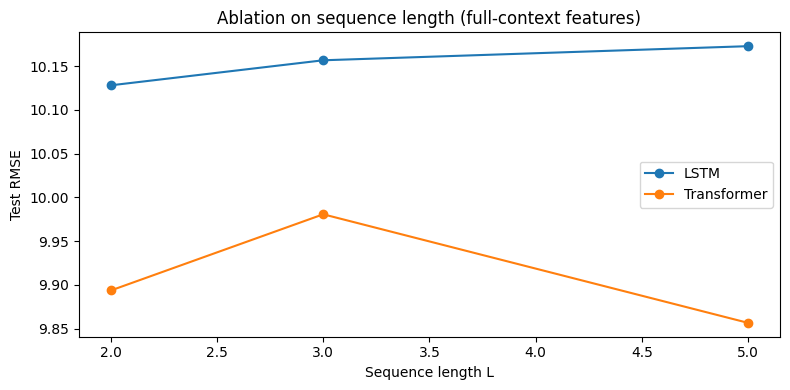

In [10]:
# Summary tables
display(new_win_metrics)
display(new_efficiency_metrics)

# Residual-learning ablation using the SAME setup as the main deep-model pipeline

new_pythag_col = None
for c in ["pythag_win_pct", "pythag_win_pct_183"]:
    if c in df.columns:
        new_pythag_col = c
        break

new_full_context = ["W", "payroll_z_by_year", "R", "RA", "W_pct", "log_payroll"]
if new_pythag_col is not None:
    new_full_context.append(new_pythag_col)

new_feature_sets = {
    "payroll_only": [c for c in ["payroll_z_by_year", "log_payroll"] if c in df.columns],
    "full_context": [c for c in new_full_context if c in df.columns],
}

class NewSeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def new_scale_sequences_by_train(Xtr_in, Xva_in, Xte_in):
    mu = Xtr_in.mean(axis=(0, 1), keepdims=True)
    sd = Xtr_in.std(axis=(0, 1), keepdims=True)
    sd[sd == 0] = 1.0
    return (Xtr_in - mu) / sd, (Xva_in - mu) / sd, (Xte_in - mu) / sd

def new_make_sequences(df_in, seq_len, feature_cols, target_col="resid_next", base_col="W_hat"):
    work = df_in.sort_values(["teamID", "yearID"]).reset_index(drop=True)
    X_list, y_list, y_year_list, team_list, last_year_list, base_list = [], [], [], [], [], []

    for team, g in work.groupby("teamID"):
        g = g.sort_values("yearID").reset_index(drop=True)

        for i in range(seq_len - 1, len(g)):
            y = g.loc[i, target_col]
            b = g.loc[i, base_col]
            if pd.isna(y) or pd.isna(b):
                continue

            window = g.loc[i - seq_len + 1:i, feature_cols].to_numpy(dtype=np.float32)
            if np.isnan(window).any():
                continue

            X_list.append(window)
            y_list.append(float(y))
            y_year_list.append(int(g.loc[i, "yearID"]))
            team_list.append(team)
            last_year_list.append(int(g.loc[i, "yearID"]))
            base_list.append(float(b))

    if len(X_list) == 0:
        return (
            np.zeros((0, seq_len, len(feature_cols)), dtype=np.float32),
            np.zeros((0,), dtype=np.float32),
            np.zeros((0,), dtype=np.int32),
            np.array([], dtype=object),
            np.zeros((0,), dtype=np.int32),
            np.zeros((0,), dtype=np.float32),
        )

    return (
        np.stack(X_list, axis=0),
        np.array(y_list, dtype=np.float32),
        np.array(y_year_list, dtype=np.int32),
        np.array(team_list),
        np.array(last_year_list, dtype=np.int32),
        np.array(base_list, dtype=np.float32),
    )

def new_train_seq_model(model, Xtr_in, ytr_in, Xva_in, yva_in, epochs=20, batch_size=128, lr=3e-4):
    train_loader = DataLoader(NewSeqDataset(Xtr_in, ytr_in), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(NewSeqDataset(Xva_in, yva_in), batch_size=batch_size, shuffle=False)
    return train_torch(model, train_loader, val_loader, epochs=epochs, lr=lr, weight_decay=1e-3, device=device)

def new_predict_seq_model(model, X_in):
    model.eval()
    preds = []
    with torch.no_grad():
        loader = DataLoader(
            NewSeqDataset(X_in, np.zeros((len(X_in),), dtype=np.float32)),
            batch_size=256,
            shuffle=False
        )
        for xb, _ in loader:
            preds.append(model(xb.to(device)).detach().cpu().numpy().reshape(-1))
    return np.concatenate(preds) if preds else np.array([])

new_ablation_rows = []

for new_seq_len in [2, 3, 5]:
    for new_feature_name, new_feature_cols in new_feature_sets.items():
        if len(new_feature_cols) == 0:
            continue

        new_df_seq = df.dropna(
            subset=["teamID", "yearID", "resid_next", "W_hat"] + new_feature_cols
        ).copy()

        X_all_new, y_all_new, y_year_all_new, team_all_new, last_year_all_new, b_all_new = new_make_sequences(
            new_df_seq,
            seq_len=new_seq_len,
            feature_cols=new_feature_cols,
            target_col="resid_next",
            base_col="W_hat",
        )

        new_train_mask = (y_year_all_new >= 1985) & (y_year_all_new <= 2008)
        new_val_mask   = (y_year_all_new >= 2009) & (y_year_all_new <= 2012)
        new_test_mask  = (y_year_all_new >= 2013) & (y_year_all_new <= 2016)

        Xtr_new, ytr_new = X_all_new[new_train_mask], y_all_new[new_train_mask]
        Xva_new, yva_new = X_all_new[new_val_mask],   y_all_new[new_val_mask]
        Xte_new, yte_new = X_all_new[new_test_mask],  y_all_new[new_test_mask]

        btr_new = b_all_new[new_train_mask]
        bva_new = b_all_new[new_val_mask]
        bte_new = b_all_new[new_test_mask]

        if min(len(Xtr_new), len(Xva_new), len(Xte_new)) == 0:
            continue

        Xtr_new, Xva_new, Xte_new = new_scale_sequences_by_train(Xtr_new, Xva_new, Xte_new)

        # LSTM
        new_lstm = LSTMRegressor(input_dim=Xtr_new.shape[2], hidden_dim=32, num_layers=1)
        new_lstm = new_train_seq_model(new_lstm, Xtr_new, ytr_new, Xva_new, yva_new, epochs=20, lr=3e-4)
        new_lstm_pred_resid = new_predict_seq_model(new_lstm, Xte_new)
        new_lstm_pred_wins = bte_new + new_lstm_pred_resid
        new_true_wins = bte_new + yte_new

        new_ablation_rows.append({
            "Model": "LSTM",
            "Seq_Len": new_seq_len,
            "Feature_Set": new_feature_name,
            "RMSE": float(np.sqrt(mean_squared_error(new_true_wins, new_lstm_pred_wins))),
            "MAE": float(mean_absolute_error(new_true_wins, new_lstm_pred_wins)),
            "R2": float(r2_score(new_true_wins, new_lstm_pred_wins)),
        })

        # Transformer
        new_trm = TransformerRegressor(
            input_dim=Xtr_new.shape[2],
            d_model=32,
            nhead=4,
            num_layers=1,
            max_len=max(8, new_seq_len)
        )
        new_trm = new_train_seq_model(new_trm, Xtr_new, ytr_new, Xva_new, yva_new, epochs=20, lr=3e-4)
        new_trm_pred_resid = new_predict_seq_model(new_trm, Xte_new)
        new_trm_pred_wins = bte_new + new_trm_pred_resid

        new_ablation_rows.append({
            "Model": "Transformer",
            "Seq_Len": new_seq_len,
            "Feature_Set": new_feature_name,
            "RMSE": float(np.sqrt(mean_squared_error(new_true_wins, new_trm_pred_wins))),
            "MAE": float(mean_absolute_error(new_true_wins, new_trm_pred_wins)),
            "R2": float(r2_score(new_true_wins, new_trm_pred_wins)),
        })

new_ablation = pd.DataFrame(new_ablation_rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
display(new_ablation)

plt.figure(figsize=(8, 4))
for new_model_name in ["LSTM", "Transformer"]:
    new_plot_df = new_ablation[
        (new_ablation["Model"] == new_model_name) &
        (new_ablation["Feature_Set"] == "full_context")
    ].sort_values("Seq_Len")

    if len(new_plot_df) > 0:
        plt.plot(new_plot_df["Seq_Len"], new_plot_df["RMSE"], marker="o", label=new_model_name)

plt.xlabel("Sequence length L")
plt.ylabel("Test RMSE")
plt.title("Ablation on sequence length (full-context features)")
plt.legend()
plt.tight_layout()
plt.show()

## Toronto Blue Jays Case Study

This section uses the league-trained models above as a focused case study on the **Toronto Blue Jays (TOR)**. Here we evaluate **Blue Jays-specific forecasting accuracy** within the held-out **test window (2013–2016)** and interpret **payroll efficiency** through model residuals, defined as actual wins minus predicted wins.

We compare the classical **ridge baseline** with the **Transformer** sequence model. The ridge model provides an interpretable fixed-lag benchmark, while the Transformer captures longer temporal dependencies across team-season sequences. This case study gives a concrete team-level illustration of how the trained models behave on a historically meaningful MLB franchise.

### Blue Jays Temporal Trajectory

Before looking at held-out Blue Jays forecasts, it is helpful to visualize the team’s performance over time. The plot below shows actual wins together with a domain-informed benchmark based on Pythagorean expected wins. This provides temporal context for the later case-study analysis and illustrates the type of multi-season structure that deep temporal models are designed to capture.

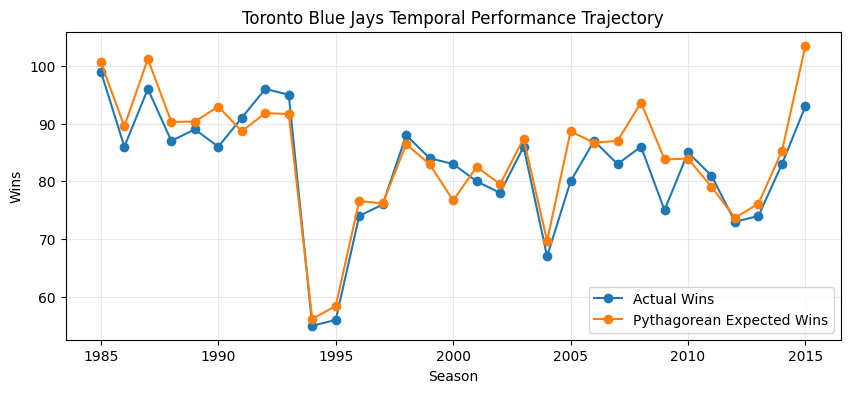

In [11]:
# Blue Jays temporal trajectory: actual wins vs Pythagorean expected wins
tor_df = df[df["teamID"] == "TOR"].copy().sort_values("yearID")

plt.figure(figsize=(10, 4))
plt.plot(tor_df["yearID"], tor_df["W"], marker="o", label="Actual Wins")
plt.plot(
    tor_df["yearID"],
    tor_df["pythag_win_pct"] * tor_df["G"],
    marker="o",
    label="Pythagorean Expected Wins"
)
plt.title("Toronto Blue Jays Temporal Performance Trajectory")
plt.xlabel("Season")
plt.ylabel("Wins")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

,teamID,yearID,target_year,actual_wins,pred_ridge_wins,ridge_efficiency
766,TOR,2012,2013,74.0,80.277841,-6.277841
767,TOR,2013,2014,83.0,77.871713,5.128287
768,TOR,2014,2015,93.0,77.981183,15.018817
769,TOR,2015,2016,89.0,78.822329,10.177671


,teamID,yearID,target_year,baseline_wins,actual_wins,pred_trm_wins,trm_efficiency
0,TOR,2013,2014,77.871712,83.0,76.586784,6.413216
1,TOR,2014,2015,77.981186,93.0,78.436569,14.563431
2,TOR,2015,2016,78.822327,89.0,80.671494,8.328506


,target_year,actual_wins,pred_ridge_wins,ridge_efficiency,pred_trm_wins,trm_efficiency
0,2013,74.0,80.277841,-6.277841,NaN,NaN
1,2014,83.0,77.871713,5.128287,76.586784,6.413216
2,2015,93.0,77.981183,15.018817,78.436569,14.563431
3,2016,89.0,78.822329,10.177671,80.671494,8.328506


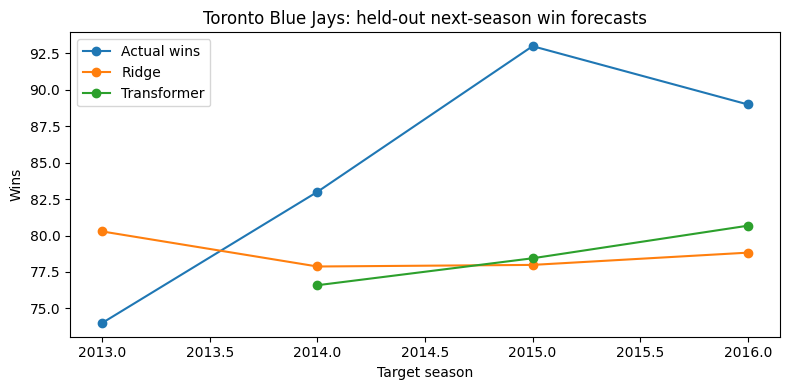

In [12]:

# Ridge baseline forecasts
# df_lagged rows at year t predict W_next for year t+1
ridge_tor = df_lagged[
    (df_lagged["teamID"] == "TOR") &
    (df_lagged["yearID"] >= 2012) &
    (df_lagged["yearID"] <= 2015)
].copy()

ridge_tor["target_year"] = ridge_tor["yearID"] + 1
ridge_tor["pred_ridge_wins"] = ridge_model.predict(ridge_tor[LAG_FEATURES])
ridge_tor["actual_wins"] = ridge_tor["W_next"]
ridge_tor["ridge_efficiency"] = ridge_tor["actual_wins"] - ridge_tor["pred_ridge_wins"]

ridge_tor_out = ridge_tor[[
    "teamID", "yearID", "target_year", "actual_wins",
    "pred_ridge_wins", "ridge_efficiency"
]].copy()

display(ridge_tor_out)


# Transformer forecasts
team_te = team_all[test_mask]
last_year_te = last_year_all[test_mask]

trm_tor_mask = (team_te == "TOR")

trm_tor = pd.DataFrame({
    "teamID": team_te[trm_tor_mask],
    "yearID": last_year_te[trm_tor_mask],
    "target_year": last_year_te[trm_tor_mask] + 1,
    "baseline_wins": bte[trm_tor_mask],
    "actual_wins": bte[trm_tor_mask] + yte[trm_tor_mask],
    "pred_trm_wins": bte[trm_tor_mask] + pred_trm_resid[trm_tor_mask],
})

trm_tor["trm_efficiency"] = trm_tor["actual_wins"] - trm_tor["pred_trm_wins"]

display(trm_tor)


# Merge for direct comparison 
tor_compare = ridge_tor_out[[
    "target_year", "actual_wins", "pred_ridge_wins", "ridge_efficiency"
]].merge(
    trm_tor[[
        "target_year", "actual_wins", "pred_trm_wins", "trm_efficiency"
    ]],
    on=["target_year", "actual_wins"],
    how="outer"
).sort_values("target_year").reset_index(drop=True)

display(tor_compare)


plt.figure(figsize=(8, 4))
plt.plot(tor_compare["target_year"], tor_compare["actual_wins"], marker="o", label="Actual wins")
plt.plot(tor_compare["target_year"], tor_compare["pred_ridge_wins"], marker="o", label="Ridge")
plt.plot(tor_compare["target_year"], tor_compare["pred_trm_wins"], marker="o", label="Transformer")
plt.xlabel("Target season")
plt.ylabel("Wins")
plt.title("Toronto Blue Jays: held-out next-season win forecasts")
plt.legend()
plt.tight_layout()
plt.show()